# 1-Hour and 2-Hour Baseline Model (Santi)

### Imports

In [12]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

### Setup

In [13]:
RANDOM_STATE = 207
VALIDATION_START = pd.Timestamp('2024-01-01')
TEST_START = pd.Timestamp('2025-01-01')
TARGET = 'outcome'

CLASS_ORDER = list(range(9))
CLASS_LABELS = {
    0: 'Early (<= 0 hr)',
    1: '0-1 hr',
    2: '1-2 hr',
    3: '2-3 hr',
    4: '3-4 hr',
    5: '4-5 hr',
    6: '5-6 hr',
    7: '6+ hr',
    8: 'Cancelled',
}

NUMERIC_FEATURES = [
    'scheduled_elapsed_time_minutes',
    'year',
    'month',
    'day_of_week',
    'is_weekend',
    'sched_dep_hour',
    'days_until_holiday',
    'days_from_holiday',
    'year_mfr',
    'no_seats',
    'visibility',
    'ceiling_height',
    'wind_speed',
    'wind_direction',
    'temperature',
    'dew_point_temperature',
    'relative_humidity',
    'altimeter',
    'aircraft_age',
    'week_num',
    'temperature_dewpoint_spread',
    'airport_delay_average_1h',
    'airport_delay_stddev_1h',
    'airport_departures_observed_1h',
]

CATEGORICAL_FEATURES = [
    'carrier_code',
    'destination_airport',
    'model',
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')

### Project Paths

In [14]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for directory in [start, *start.parents]:
        if (directory / 'Merged_EDA' / 'combined_data').exists():
            return directory
    raise FileNotFoundError('Could not find the project root that contains Merged_EDA/combined_data.')


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'Merged_EDA' / 'combined_data'

print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')

Project root: C:\Users\smeri\OneDrive\Desktop\MIDS Coursework\207-Summer26-FinalProject-MLModel
Data directory: C:\Users\smeri\OneDrive\Desktop\MIDS Coursework\207-Summer26-FinalProject-MLModel\Merged_EDA\combined_data


### Load and Split Functions

In [15]:
def load_horizon_dataset(csv_name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / csv_name)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['scheduled_dep_dt'] = pd.to_datetime(df['scheduled_dep_dt'], errors='coerce')
    df['actual_dep_dt'] = pd.to_datetime(df['actual_dep_dt'], errors='coerce')
    df[TARGET] = pd.to_numeric(df[TARGET], errors='raise').astype(int)
    df = df.sort_values('scheduled_dep_dt').reset_index(drop=True)
    return df

def temporal_split(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    return {
        'Train': df[df['date'] < VALIDATION_START].copy(),
        'Validation': df[(df['date'] >= VALIDATION_START) & (df['date'] < TEST_START)].copy(),
        'Test': df[df['date'] >= TEST_START].copy(),
    }

def build_split_summary(splits: dict[str, pd.DataFrame]) -> pd.DataFrame:
    total_rows = sum(len(frame) for frame in splits.values())
    rows = []
    for split_name, frame in splits.items():
        rows.append({
            'split': split_name,
            'rows': len(frame),
            'share_of_rows': len(frame) / total_rows,
            'start_date': frame['date'].min().date(),
            'end_date': frame['date'].max().date(),
        })
    return pd.DataFrame(rows)

### Preprocessing Functions

In [16]:
def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    return ColumnTransformer([
        ('numeric', numeric_pipeline, NUMERIC_FEATURES),
        ('categorical', categorical_pipeline, CATEGORICAL_FEATURES),
    ], verbose_feature_names_out=False)

def compute_sqrt_class_weights(y: pd.Series) -> dict[int, float]:
    classes = np.sort(y.unique())
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return {int(class_id): float(np.sqrt(weight)) for class_id, weight in zip(classes, weights)}

### Model Building Function

In [17]:
def build_baseline_model(num_features: int, num_classes: int) -> tf.keras.Model:
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(num_features,)),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

### Plotting and Evaluation Functions

In [18]:
def plot_target_distribution(y: pd.Series, title: str) -> None:
    counts = y.value_counts().reindex(CLASS_ORDER, fill_value=0)
    plot_df = pd.DataFrame({
        'class_label': [CLASS_LABELS[class_id] for class_id in CLASS_ORDER],
        'count': counts.values,
    })

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=plot_df, x='class_label', y='count', ax=ax, color='#4C72B0')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Outcome class')
    ax.set_ylabel('Row count')
    ax.tick_params(axis='x', rotation=35)

    for patch, count in zip(ax.patches, plot_df['count']):
        ax.annotate(
            f'{count:,}',
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 4),
            textcoords='offset points',
        )

    plt.tight_layout()
    plt.show()

def plot_training_history(history: tf.keras.callbacks.History, title_prefix: str) -> None:
    history_df = pd.DataFrame(history.history)
    epochs = history_df.index + 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history_df['loss'], marker='o', label='Training Loss')
    axes[0].plot(epochs, history_df['val_loss'], marker='o', label='Validation Loss')
    axes[0].set_title(f'{title_prefix}: Training vs Validation Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history_df['accuracy'], marker='o', label='Training Accuracy')
    axes[1].plot(epochs, history_df['val_accuracy'], marker='o', label='Validation Accuracy')
    axes[1].set_title(f'{title_prefix}: Training vs Validation Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def classification_report_frame(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        target_names=[CLASS_LABELS[class_id] for class_id in CLASS_ORDER],
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).transpose()

def plot_confusion(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 7))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        display_labels=[CLASS_LABELS[class_id] for class_id in CLASS_ORDER],
        cmap='Blues',
        colorbar=False,
        xticks_rotation=45,
        ax=ax,
    )
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

def evaluate_split_metrics(model: tf.keras.Model, split_data: dict[str, tuple[np.ndarray, np.ndarray]]) -> pd.DataFrame:
    rows = []
    for split_name, (features, labels) in split_data.items():
        loss, accuracy = model.evaluate(features, labels, verbose=0)
        rows.append({
            'split': split_name,
            'loss': loss,
            'accuracy': accuracy,
        })
    return pd.DataFrame(rows)

## End-to-End baseline

In [ ]:
def run_baseline(csv_name: str, horizon_name: str, epochs: int = 50, batch_size: int = 512) -> dict[str, object]:
    df = load_horizon_dataset(csv_name)
    splits = temporal_split(df)

    print(f'{horizon_name}: loaded {len(df):,} rows from {csv_name}')
    display(build_split_summary(splits))
    plot_target_distribution(splits['Train'][TARGET], f'{horizon_name}: training class distribution')

    X_train = splits['Train'][FEATURE_COLUMNS]
    y_train = splits['Train'][TARGET]
    X_val = splits['Validation'][FEATURE_COLUMNS]
    y_val = splits['Validation'][TARGET]
    X_test = splits['Test'][FEATURE_COLUMNS]
    y_test = splits['Test'][TARGET]

    preprocessor = build_preprocessor()
    X_train_processed = preprocessor.fit_transform(X_train).astype('float32')
    X_val_processed = preprocessor.transform(X_val).astype('float32')
    X_test_processed = preprocessor.transform(X_test).astype('float32')

    print(
        f'Encoded feature count: {X_train_processed.shape[1]:,} | '
        f'Train: {X_train_processed.shape} | Validation: {X_val_processed.shape} | Test: {X_test_processed.shape}'
    )

    class_weights = compute_sqrt_class_weights(y_train)
    class_weight_table = pd.DataFrame({
        'class_id': list(class_weights.keys()),
        'class_label': [CLASS_LABELS[class_id] for class_id in class_weights.keys()],
        'sqrt_class_weight': list(class_weights.values()),
    })
    display(class_weight_table.round(3))

    model = build_baseline_model(
        num_features=X_train_processed.shape[1],
        num_classes=len(CLASS_ORDER),
    )
    print(f'Baseline model: single Dense({len(CLASS_ORDER)}, softmax) layer over {X_train_processed.shape[1]:,} encoded features.')

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    )

    history = model.fi(
        X_train_processed,
        y_train.to_numpy(),
        validation_data=(X_val_processed, y_val.to_numpy()),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=0,
    )

    plot_training_history(history, horizon_name)

    split_metrics = evaluate_split_metrics(model, {
        'Train': (X_train_processed, y_train.to_numpy()),
        'Validation': (X_val_processed, y_val.to_numpy()),
        'Test': (X_test_processed, y_test.to_numpy()),
    })
    display(split_metrics.round(4))

    test_probabilities = model.predict(X_test_processed, batch_size=batch_size, verbose=0)
    test_predictions = np.argmax(test_probabilities, axis=1)

    report_df = classification_report_frame(y_test, test_predictions)
    display(report_df.round(3))
    plot_confusion(y_test, test_predictions, f'{horizon_name}: confusion matrix on the test set')

    summary_row = {
        'horizon': horizon_name,
        'epochs_trained': len(history.history['loss']),
        'train_accuracy': split_metrics.loc[split_metrics['split'].eq('Train'), 'accuracy'].iloc[0],
        'validation_accuracy': split_metrics.loc[split_metrics['split'].eq('Validation'), 'accuracy'].iloc[0],
        'test_accuracy': split_metrics.loc[split_metrics['split'].eq('Test'), 'accuracy'].iloc[0],
        'test_loss': split_metrics.loc[split_metrics['split'].eq('Test'), 'loss'].iloc[0],
        'test_balanced_accuracy': balanced_accuracy_score(y_test, test_predictions),
        'test_macro_f1': f1_score(y_test, test_predictions, average='macro', zero_division=0),
    }

    print(f"{horizon_name}: trained for {summary_row['epochs_trained']} epochs.")
    print(
        f"Test accuracy = {summary_row['test_accuracy']:.4f}, "
        f"balanced accuracy = {summary_row['test_balanced_accuracy']:.4f}, "
        f"macro F1 = {summary_row['test_macro_f1']:.4f}."
    )

    return {
        'data': df,
        'split_metrics': split_metrics,
        'report': report_df,
        'summary_row': summary_row,
        'history': history,
    }

## 1-Hour Baseline

1-Hour: loaded 334,086 rows from combined_data_1h.csv


,split,rows,share_of_rows,start_date,end_date
0,Train,151575,0.453701,2022-01-01,2023-12-31
1,Validation,84531,0.253022,2024-01-01,2024-12-31
2,Test,97980,0.293278,2025-01-01,2026-04-30


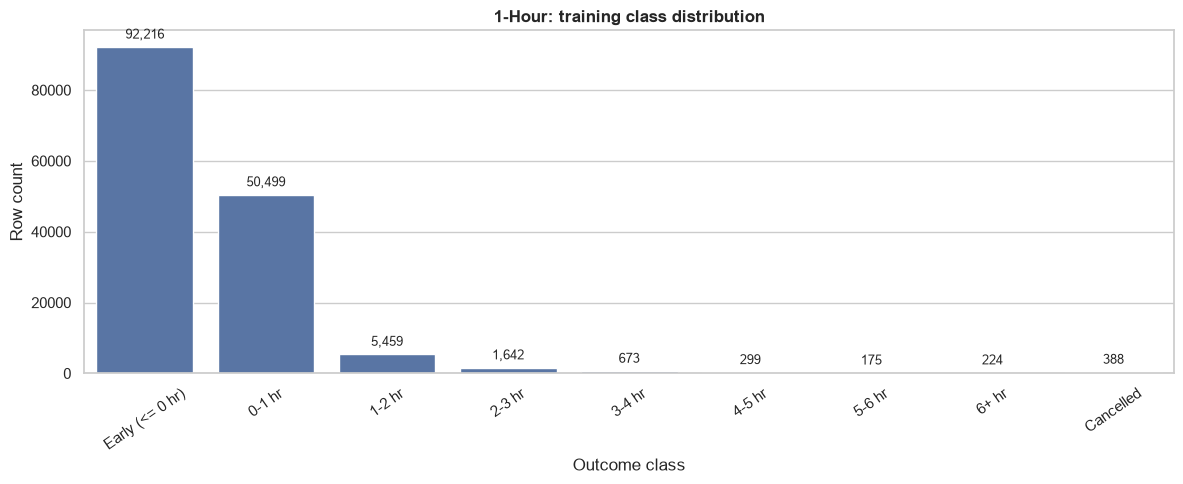

Encoded feature count: 173 | Train: (151575, 173) | Validation: (84531, 173) | Test: (97980, 173)


,class_id,class_label,sqrt_class_weight
0,0,Early (<= 0 hr),0.427
1,1,0-1 hr,0.577
2,2,1-2 hr,1.756
3,3,2-3 hr,3.203
4,4,3-4 hr,5.002
5,5,4-5 hr,7.505
6,6,5-6 hr,9.810
7,7,6+ hr,8.671
8,8,Cancelled,6.588


Baseline model: single Dense(9, softmax) layer over 173 encoded features.


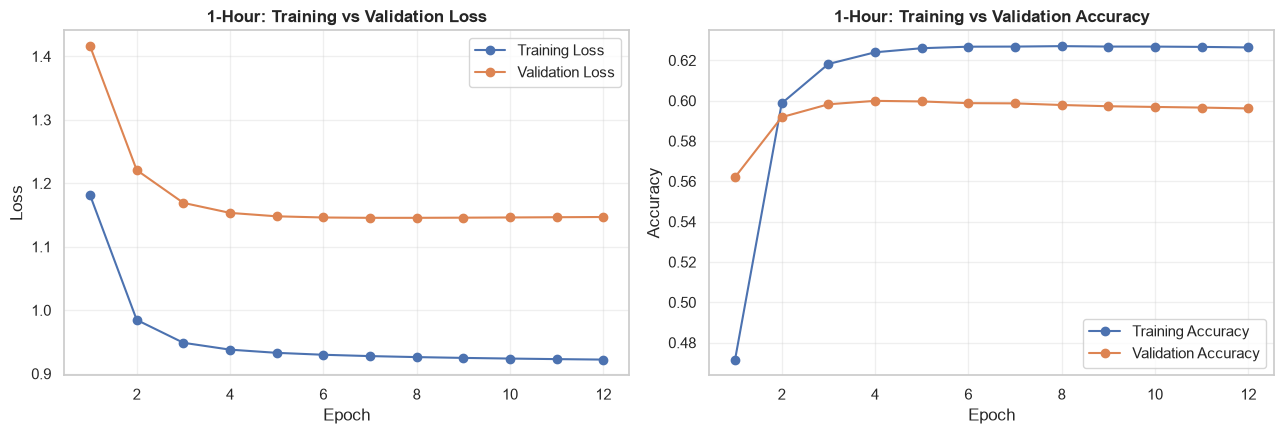

,split,loss,accuracy
0,Train,1.0282,0.6267
1,Validation,1.1455,0.5987
2,Test,1.2048,0.6142


,precision,recall,f1-score,support
Early (<= 0 hr),0.712,0.763,0.737,62608.000
0-1 hr,0.424,0.426,0.425,28762.000
1-2 hr,0.124,0.036,0.055,3951.000
2-3 hr,0.029,0.002,0.004,1310.000
3-4 hr,0.000,0.000,0.000,523.000
4-5 hr,0.000,0.000,0.000,246.000
5-6 hr,0.000,0.000,0.000,112.000
6+ hr,0.008,0.029,0.013,171.000
Cancelled,0.000,0.000,0.000,297.000
accuracy,0.614,0.614,0.614,0.614


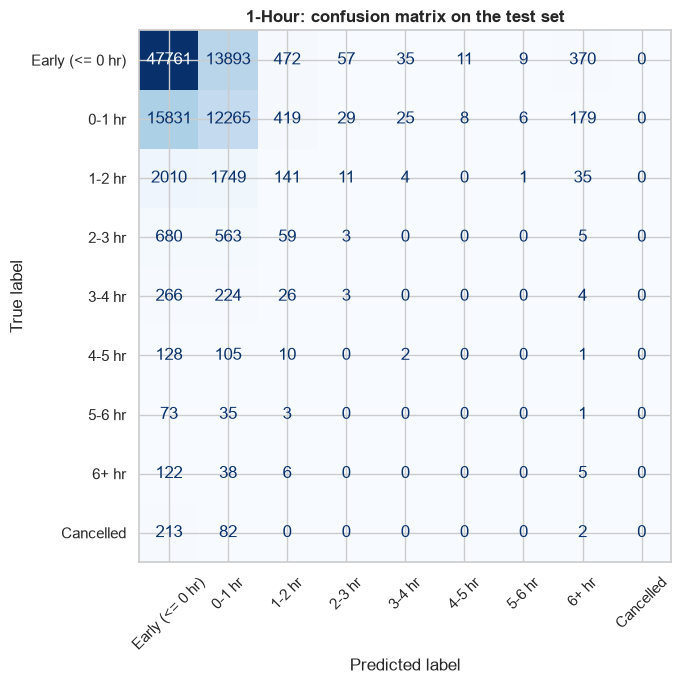

1-Hour: trained for 12 epochs.
Test accuracy = 0.6142, balanced accuracy = 0.1396, macro F1 = 0.1371.


In [20]:
one_hour_results = run_baseline(
    csv_name='combined_data_1h.csv',
    horizon_name='1-Hour',
    epochs=50,
    batch_size=512,
)

## 2-Hour Baseline

2-Hour: loaded 335,918 rows from combined_data_2h.csv


,split,rows,share_of_rows,start_date,end_date
0,Train,151962,0.452378,2022-01-01,2023-12-31
1,Validation,84932,0.252836,2024-01-01,2024-12-31
2,Test,99024,0.294786,2025-01-01,2026-04-30


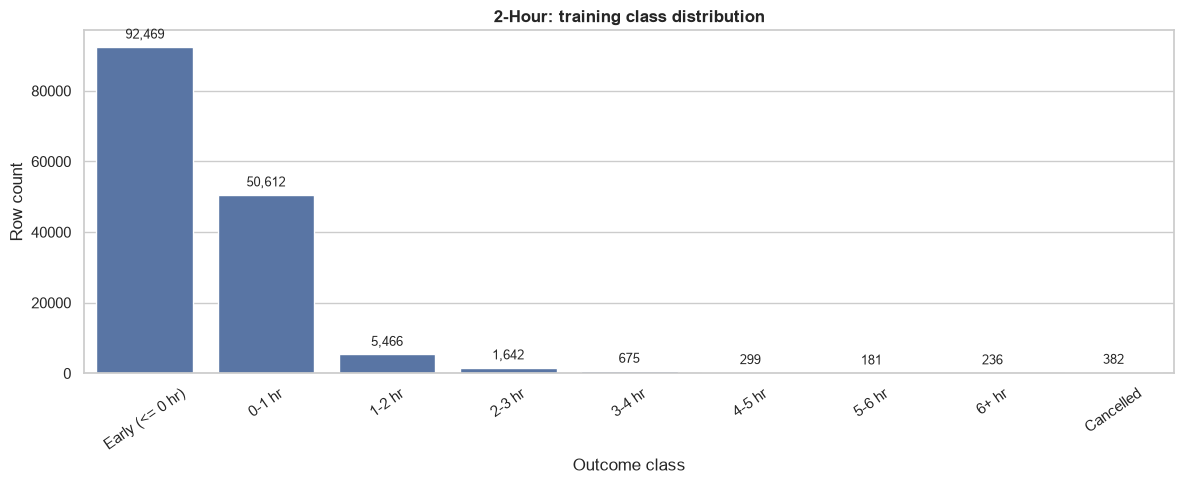

Encoded feature count: 173 | Train: (151962, 173) | Validation: (84932, 173) | Test: (99024, 173)


,class_id,class_label,sqrt_class_weight
0,0,Early (<= 0 hr),0.427
1,1,0-1 hr,0.578
2,2,1-2 hr,1.758
3,3,2-3 hr,3.207
4,4,3-4 hr,5.001
5,5,4-5 hr,7.515
6,6,5-6 hr,9.658
7,7,6+ hr,8.458
8,8,Cancelled,6.648


Baseline model: single Dense(9, softmax) layer over 173 encoded features.


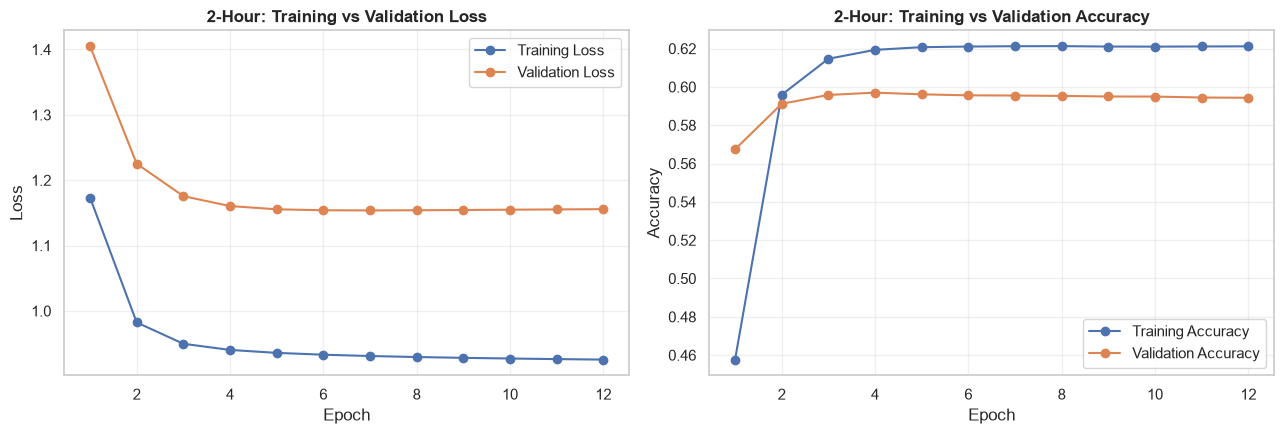

,split,loss,accuracy
0,Train,1.0310,0.6224
1,Validation,1.1538,0.5955
2,Test,1.2282,0.6015


,precision,recall,f1-score,support
Early (<= 0 hr),0.701,0.764,0.731,63389.000
0-1 hr,0.409,0.377,0.393,28909.000
1-2 hr,0.087,0.059,0.070,4042.000
2-3 hr,0.000,0.000,0.000,1350.000
3-4 hr,0.048,0.002,0.004,523.000
4-5 hr,0.000,0.000,0.000,246.000
5-6 hr,0.000,0.000,0.000,107.000
6+ hr,0.005,0.012,0.007,163.000
Cancelled,0.000,0.000,0.000,295.000
accuracy,0.601,0.601,0.601,0.601


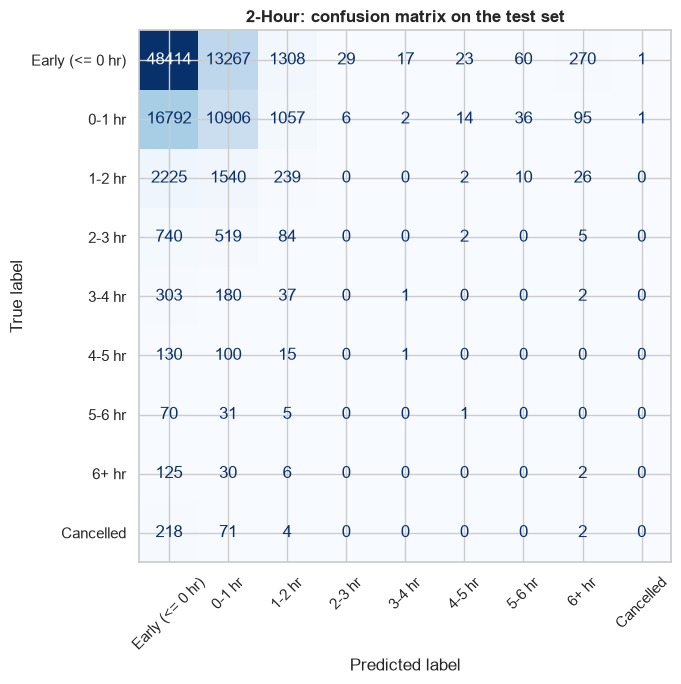

2-Hour: trained for 12 epochs.
Test accuracy = 0.6015, balanced accuracy = 0.1349, macro F1 = 0.1339.


In [21]:
two_hour_results = run_baseline(
    csv_name='combined_data_2h.csv',
    horizon_name='2-Hour',
    epochs=50,
    batch_size=512,
)

The wide gap between overall accuracy and balanced accuracy shows that the baseline still favors the majority classes.

## Final Comparison

,horizon,epochs_trained,train_accuracy,validation_accuracy,test_accuracy,test_loss,test_balanced_accuracy,test_macro_f1
0,1-Hour,12,0.6267,0.5987,0.6142,1.2048,0.1396,0.1371
1,2-Hour,12,0.6224,0.5955,0.6015,1.2282,0.1349,0.1339


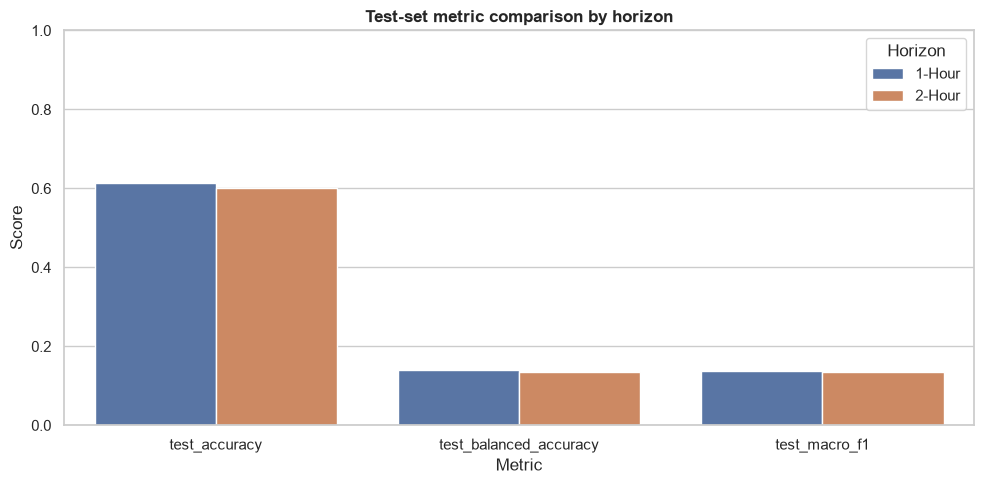

Higher test accuracy on the current data: 1-Hour (0.6142).


In [22]:
comparison_df = pd.DataFrame([
    one_hour_results['summary_row'],
    two_hour_results['summary_row'],
]).round(4)

display(comparison_df)

plot_df = comparison_df.melt(
    id_vars='horizon',
    value_vars=['test_accuracy', 'test_balanced_accuracy', 'test_macro_f1'],
    var_name='metric',
    value_name='score',
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x='metric', y='score', hue='horizon', ax=ax)
ax.set_title('Test-set metric comparison by horizon', fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(title='Horizon')
plt.tight_layout()
plt.show()

best_horizon = comparison_df.sort_values('test_accuracy', ascending=False).iloc[0]
print(f"Higher test accuracy on the current data: {best_horizon['horizon']} ({best_horizon['test_accuracy']:.4f}).")

Both horizons still show much lower balanced accuracy than raw accuracy, so the next improvement step should focus on minority-class recall rather than accuracy alone.